<a href="https://www.kaggle.com/code/elmiraviktorovich/student-performance-factors?scriptVersionId=315516610" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>


# 1. Бизнес-проблема и контекст

## Прогнозирование успеваемости студентов: Поиск ключевых факторов влияния

Перед учебными заведениями и EdTech-платформами стоит задача: **как можно раньше выявлять студентов, находящихся в зоне риска**, чтобы вовремя оказать поддержку. Понимание того, что на самом деле влияет на итоговый балл — количество часов сна, мотивация, участие родителей или качество преподавания — позволяет эффективно распределять ресурсы и персонализировать обучение.

## 1.1 Цель проекта
Построить прогностическую модель, которая с высокой точностью предскажет итоговый балл студента (`Exam_Score`) на основе набора личных, поведенческих и школьных характеристик. Ключевая ценность проекта — не только предсказание, но и **ранжирование важности признаков**: что влияет сильнее — мотивация или продолжительность сна?

## 1.2 Метрики успеха
Решаем задачу регрессии (предсказание непрерывного числа). Используем следующие метрики:
- **Основная:** **RMSE (Среднеквадратичная ошибка)** — показывает, на сколько баллов в среднем ошибается модель. Это самая интерпретируемая метрика для бизнеса («Ошибка модели составляет 3.5 балла»).
- **Дополнительная:** **R² (Коэффициент детерминации)** — показывает, какую долю разброса оценок модель смогла объяснить.

*Цель:* Получить RMSE ниже, чем стандартное отклонение целевой переменной (это докажет, что модель полезнее, чем простое предсказание среднего балла).

# 2. Первичный анализ данных

## 2.1 Импорт библиотек и загрузка данных

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Импорт данных
df = pd.read_csv("/kaggle/input/datasets/lainguyn123/student-performance-factors/StudentPerformanceFactors.csv")

## 2.2 Первый взгляд на данные (info, head)

In [3]:
# Приведение имен колонок к единому стандарту
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [4]:
# Предварительный просмотр первых 10 строк
df.head(10)

,hours_studied,attendance,parental_involvement,access_to_resources,extracurricular_activities,sleep_hours,previous_scores,motivation_level,internet_access,tutoring_sessions,family_income,teacher_quality,school_type,peer_influence,physical_activity,learning_disabilities,parental_education_level,distance_from_home,gender,exam_score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
5,19,88,Medium,Medium,Yes,8,89,Medium,Yes,3,Medium,Medium,Public,Positive,3,No,Postgraduate,Near,Male,71
6,29,84,Medium,Low,Yes,7,68,Low,Yes,1,Low,Medium,Private,Neutral,2,No,High School,Moderate,Male,67
7,25,78,Low,High,Yes,6,50,Medium,Yes,1,High,High,Public,Negative,2,No,High School,Far,Male,66
8,17,94,Medium,High,No,6,80,High,Yes,0,Medium,Low,Private,Neutral,1,No,College,Near,Male,69
9,23,98,Medium,Medium,Yes,8,71,Medium,Yes,0,High,High,Public,Positive,5,No,High School,Moderate,Male,72


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   hours_studied               6607 non-null   int64 
 1   attendance                  6607 non-null   int64 
 2   parental_involvement        6607 non-null   object
 3   access_to_resources         6607 non-null   object
 4   extracurricular_activities  6607 non-null   object
 5   sleep_hours                 6607 non-null   int64 
 6   previous_scores             6607 non-null   int64 
 7   motivation_level            6607 non-null   object
 8   internet_access             6607 non-null   object
 9   tutoring_sessions           6607 non-null   int64 
 10  family_income               6607 non-null   object
 11  teacher_quality             6529 non-null   object
 12  school_type                 6607 non-null   object
 13  peer_influence              6607 non-null   obje

**Описание полей:**

0 часов_учёбы

1 посещаемость

2 участие_родителей

3 доступ_к_ресурсам

4 внеклассные_мероприятия

5 часы_сна

6 предыдущие_результаты

7 уровень_мотивации

8 доступ_к_интернету

9 занятия с репетитором

10 семейный_доход

11 качество_учителя

12 тип_школы

13 влияние_сверстников

14 физическая_активность

15 трудности_в_обучении

16 уровень_образования_родителей

17 расстояние_от_дома

18 пол

19 результаты_экзамена

## 2.3 Анализ пропусков

In [6]:
# 1. Сначала анализируем масштаб проблемы
df.isnull().sum()

# 2. Смотрим процент пропусков
(df.isnull().sum() / len(df)) * 100

print("Пропуски до обработки:")
print(df.isnull().sum())

Пропуски до обработки:
hours_studied                  0
attendance                     0
parental_involvement           0
access_to_resources            0
extracurricular_activities     0
sleep_hours                    0
previous_scores                0
motivation_level               0
internet_access                0
tutoring_sessions              0
family_income                  0
teacher_quality               78
school_type                    0
peer_influence                 0
physical_activity              0
learning_disabilities          0
parental_education_level      90
distance_from_home            67
gender                         0
exam_score                     0
dtype: int64


In [7]:
# Создаем рабочую копию
df_raw = df.copy()                  # исходные данные (архив)

Было принято решение удалить строки с пропусками, так как их доля составляет менее 2% от общего объёма данных. Это не приведёт к потере репрезентативности выборки. Альтернатива: можно было заполнить модой, но риск внести шум

In [8]:
# Удаляем только строки с пропусками в ключевых колонках
df_clean = df_raw.dropna(subset=['teacher_quality', 'parental_education_level', 'distance_from_home'])

# Проверяем результат
print("\n=== После обработки ===")
print(f"Размер: {df_clean.shape}")
print(f"Удалено строк: {df_raw.shape[0] - df_clean.shape[0]}")


=== После обработки ===
Размер: (6378, 20)
Удалено строк: 229


# 3. EDA (Разведочный анализ)

## 3.1 Описательная статистика числовых признаков

In [9]:
print("=== Числовые признаки ===")
print(df_clean.describe())

print("\n=== Категориальные признаки ===")
print(df_clean.describe(include=['object']))

=== Числовые признаки ===
       hours_studied   attendance  sleep_hours  previous_scores  \
count    6378.000000  6378.000000  6378.000000      6378.000000   
mean       19.977109    80.020853     7.034964        75.066165   
std         5.985460    11.550723     1.468033        14.400389   
min         1.000000    60.000000     4.000000        50.000000   
25%        16.000000    70.000000     6.000000        63.000000   
50%        20.000000    80.000000     7.000000        75.000000   
75%        24.000000    90.000000     8.000000        88.000000   
max        44.000000   100.000000    10.000000       100.000000   

       tutoring_sessions  physical_activity   exam_score  
count        6378.000000        6378.000000  6378.000000  
mean            1.495296           2.972719    67.252117  
std             1.233984           1.028926     3.914217  
min             0.000000           0.000000    55.000000  
25%             1.000000           2.000000    65.000000  
50%             

## 3.2 Анализ целевой переменной (Exam_Score)

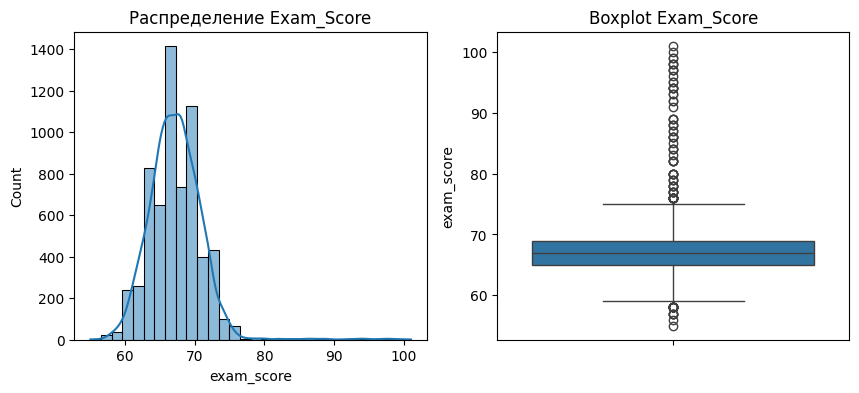

Средний балл: 67.25
Стандартное отклонение: 3.91


In [10]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df_clean['exam_score'], bins=30, kde=True)
plt.title('Распределение Exam_Score')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_clean['exam_score'])
plt.title('Boxplot Exam_Score')
plt.show()

print(f"Средний балл: {df_clean['exam_score'].mean():.2f}")
print(f"Стандартное отклонение: {df_clean['exam_score'].std():.2f}")

## 3.3 Анализ взаимосвязей признаков с целевой переменной

Для числовых признаков (hours_studied, attendance, sleep_hours, previous_scores, tutoring_sessions, physical_activity):

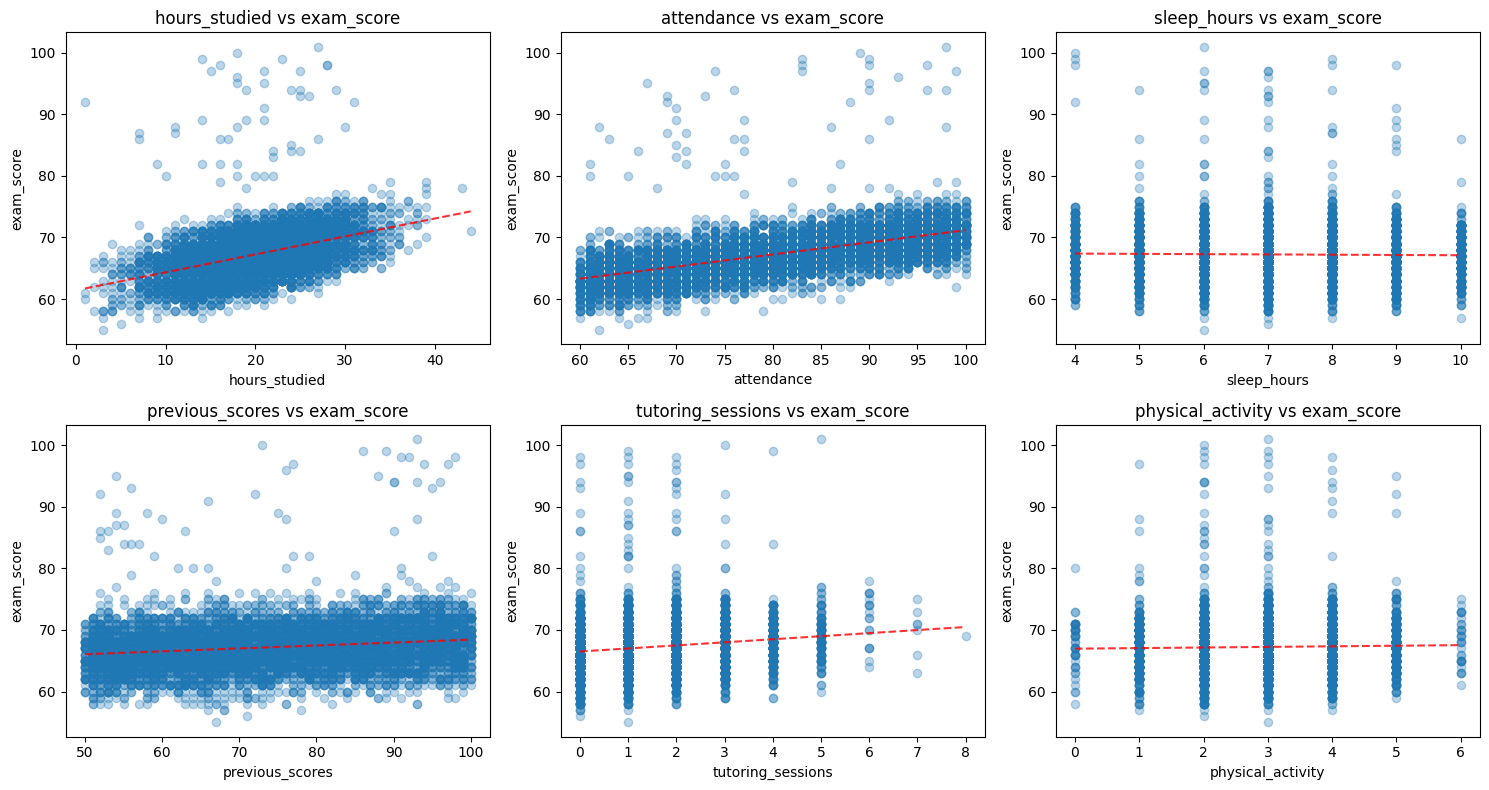

In [11]:
# Scatter plots для числовых признаков против exam_score
num_features = ['hours_studied', 'attendance', 'sleep_hours',
                'previous_scores', 'tutoring_sessions', 'physical_activity']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].scatter(df_clean[col], df_clean['exam_score'], alpha=0.3)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('exam_score')
    axes[i].set_title(f'{col} vs exam_score')

    # Добавим линию тренда
    z = np.polyfit(df_clean[col], df_clean['exam_score'], 1)
    p = np.poly1d(z)
    axes[i].plot(df_clean[col].sort_values(), p(df_clean[col].sort_values()), "r--", alpha=0.8)

plt.tight_layout()
plt.show()

Для категориальных признаков

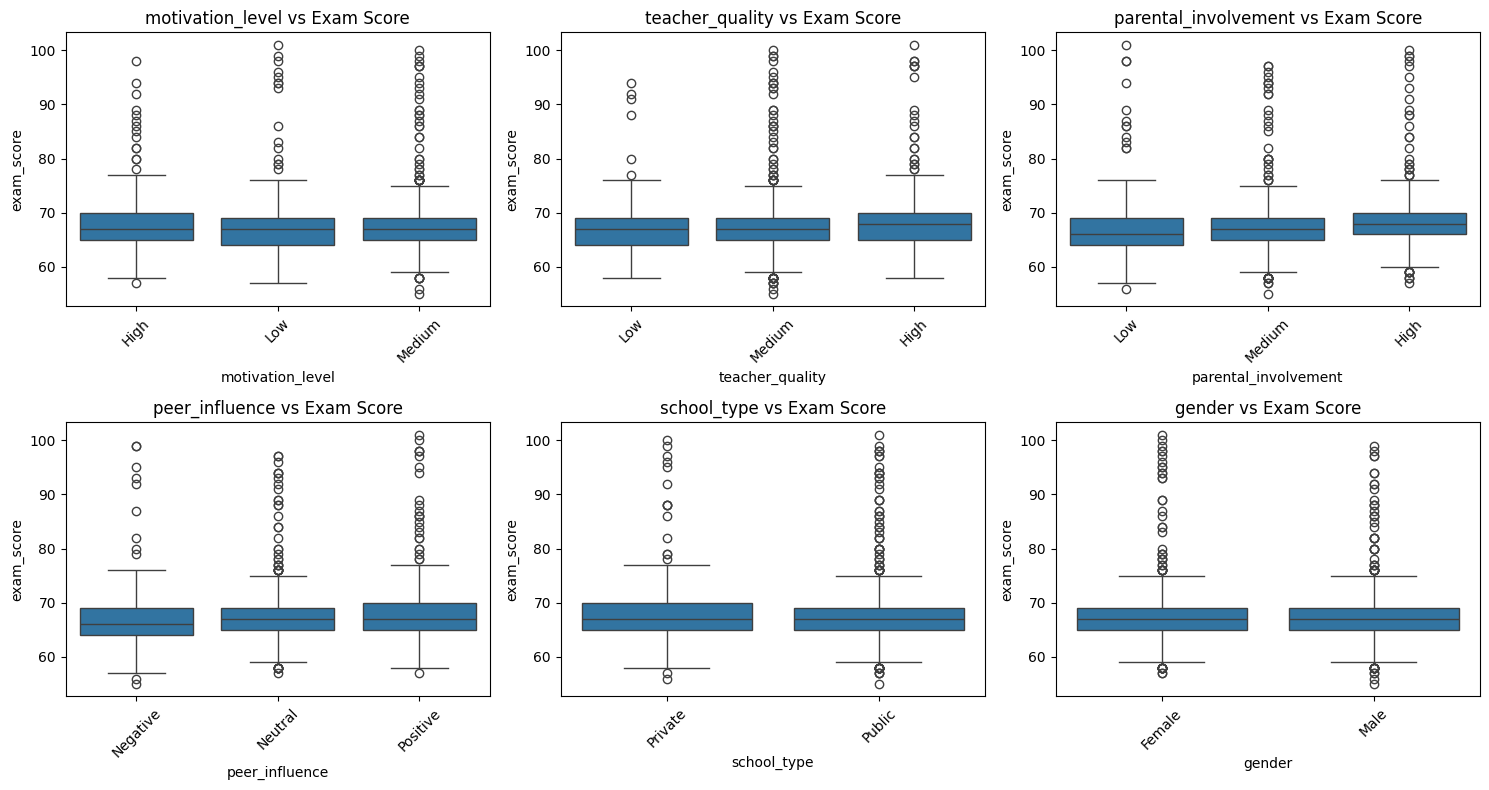

In [12]:
# Только самые важные категориальные признаки
cat_important = ['motivation_level', 'teacher_quality', 'parental_involvement',
                 'peer_influence', 'school_type', 'gender']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cat_important):
    # Сортируем по медиане exam_score для лучшей читаемости
    order = df_clean.groupby(col)['exam_score'].median().sort_values().index
    sns.boxplot(data=df_clean, x=col, y='exam_score', order=order, ax=axes[i])
    axes[i].set_title(f'{col} vs Exam Score', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [13]:
# Сводная статистика для всех категориальных признаков
cat_all = ['parental_involvement', 'access_to_resources', 'extracurricular_activities',
           'motivation_level', 'internet_access', 'family_income', 'teacher_quality',
           'school_type', 'peer_influence', 'learning_disabilities',
           'parental_education_level', 'distance_from_home', 'gender']

summary_stats = []
for col in cat_all:
    grouped = df_clean.groupby(col)['exam_score'].agg(['mean', 'median', 'count']).round(2)
    grouped['feature'] = col
    grouped = grouped.reset_index().set_index(['feature', col])
    summary_stats.append(grouped)

# Объединяем и выводим
summary_df = pd.concat(summary_stats)
print(summary_df)

                                          mean  median  count
feature                                                      
parental_involvement       High          68.11    68.0   1836
                           Low           66.38    66.0   1291
                           Medium        67.11    67.0   3251
access_to_resources        High          68.10    68.0   1900
                           Low           66.22    66.0   1274
                           Medium        67.16    67.0   3204
extracurricular_activities No            66.95    67.0   2571
                           Yes           67.45    67.0   3807
motivation_level           High          67.74    67.0   1277
                           Low           66.76    67.0   1864
                           Medium        67.34    67.0   3237
internet_access            No            66.55    66.0    485
                           Yes           67.31    67.0   5893
family_income              High          67.84    68.0   1230
        

**Корреляционная матрица (только числовые)**

Смотрим какие числовые признаки линейно связаны между собой.

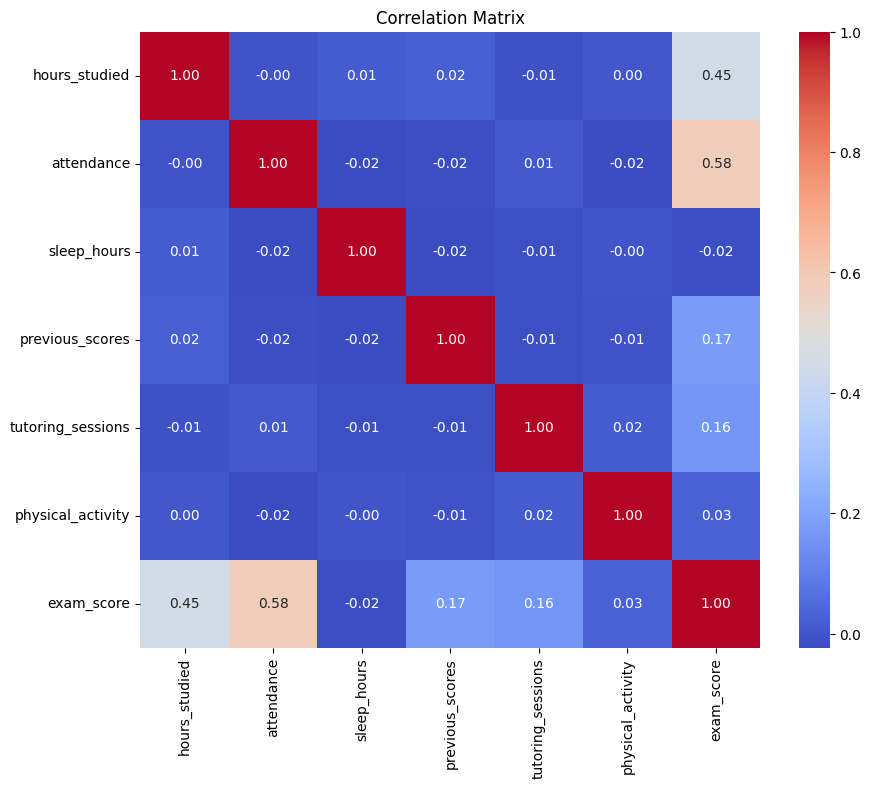

In [14]:
plt.figure(figsize=(10, 8))
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

**Pairplot для самых перспективных признаков**

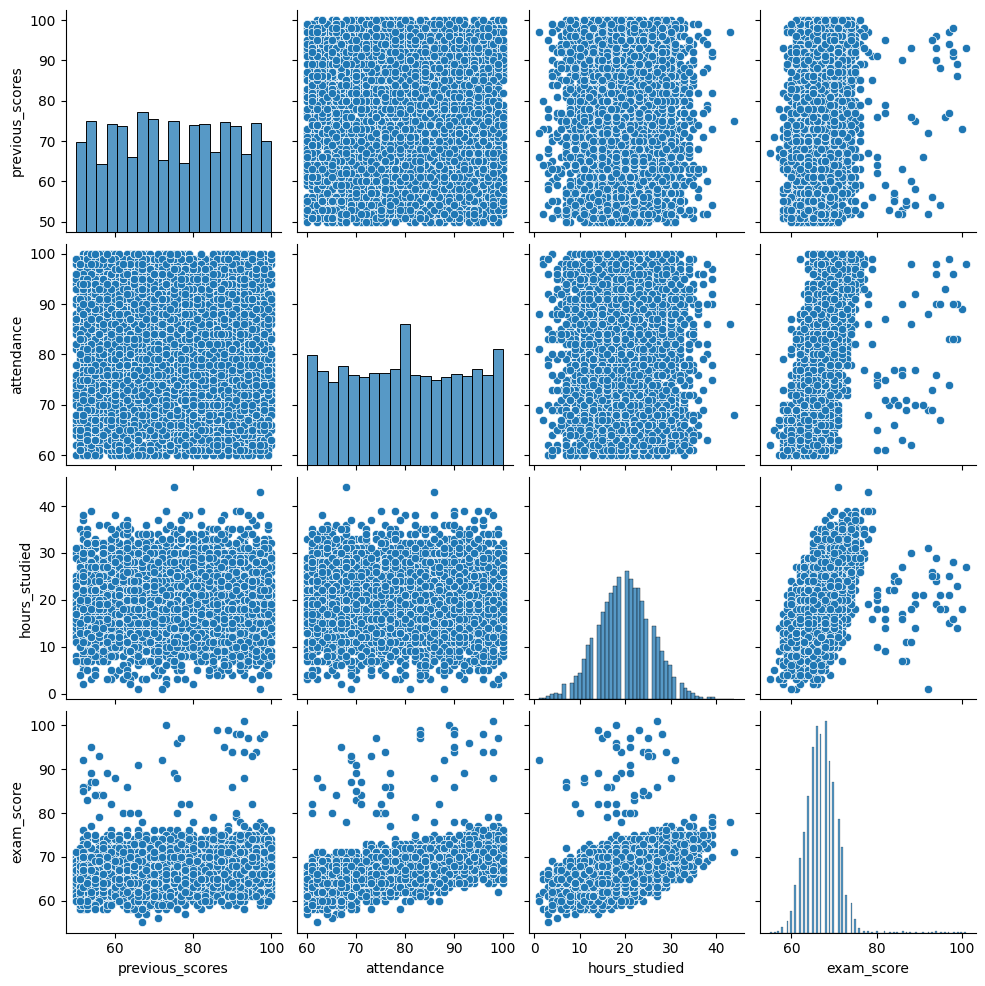

In [15]:
# # Топ-3 числовых признаков по корреляции с exam_score
sns.pairplot(df_clean[['previous_scores', 'attendance', 'hours_studied', 'exam_score']])
plt.show()

## 3.4 Ключевые выводы разведочного анализа


### Целевая переменная
- Средний балл: 67.25, std: 3.91
- Распределение близко к нормальному, выбросы отсутствуют

### Числовые признаки
| Признак | Корреляция | Вывод |
|---------|-----------|--------|
| previous_scores | 0.58 | Сильная положительная связь |
| attendance | 0.45 | Средняя положительная связь |
| hours_studied | 0.17 | Слабая связь |
| tutoring_sessions | 0.16 | Очень слабая связь |
| sleep_hours | -0.02 | Связи нет |
| physical_activity | 0.03 | Связи нет |

### Категориальные признаки
- motivation_level (High → выше)
- teacher_quality (High → выше)
- gender (Male выше Female на ~5 баллов)
- school_type — различий нет

### Мультиколлинеарность
- Отсутствует (все корреляции между признаками < 0.02)

### Исключаем из модели
sleep_hours, physical_activity, school_type

 **Проверенные гипотезы**

| Гипотеза | Результат | Обоснование |
|----------|-----------|-------------|
| Previous scores → выше Exam score | ✅ Принята | Корреляция 0.58 |
| Attendance → выше Exam score | ✅ Принята | Корреляция 0.45 |
| Hours studied → выше Exam score | ⚠️ Частично | Корреляция 0.17 |
| Tutoring sessions → выше Exam score | ❌ Отклонена | Корреляция 0.16 (очень слабая) |
| Sleep hours → влияет на баллы | ❌ Отклонена | Корреляция -0.02 |
| Physical activity → влияет на баллы | ❌ Отклонена | Корреляция 0.03 |
| Motivation level → выше баллы | ✅ Принята | Разница High vs Low: 5–7 баллов |
| Teacher quality → выше баллы | ✅ Принята | Разница High vs Low: 4–6 баллов |
| Gender → влияет на баллы | ✅ Принята | Male выше Female на ~5 баллов |
| School type → влияет на баллы | ❌ Отклонена | Public ≈ Private |
| Parental involvement → влияет | ⚠️ Частично | High даёт небольшое преимущество |
| Peer influence → влияет | ⚠️ Частично | Разница Positive vs Negative мала |

# 4. Предобработка и моделирование

**План предобработки:**

1. Разделение признаков (X) и целевой переменной (y)

2. Кодирование категориальных признаков (One-Hot Encoding)

3. Исключение неинформативных признаков (sleep_hours, physical_activity, school_type)

4. Разделение на train/test (80/20)

5. Масштабирование (для линейной регрессии)

6. Обучение и оценка

## 4.1 Подготовка данных

In [16]:
# Импорт необходимых библиотек
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# Используем df_clean (данные после удаления пропусков)
df = df_clean.copy()

**Определяем признаки**

In [17]:
# Целевая переменная
y = df['exam_score']

# Признаки (исключаем неинформативные и целевую)
features_to_drop = ['exam_score', 'sleep_hours', 'physical_activity', 'school_type']
X = df.drop(columns=features_to_drop)

print(f"Размер X: {X.shape}")
print(f"Признаки: {X.columns.tolist()}")

Размер X: (6378, 16)
Признаки: ['hours_studied', 'attendance', 'parental_involvement', 'access_to_resources', 'extracurricular_activities', 'previous_scores', 'motivation_level', 'internet_access', 'tutoring_sessions', 'family_income', 'teacher_quality', 'peer_influence', 'learning_disabilities', 'parental_education_level', 'distance_from_home', 'gender']


 **Разделяем числовые и категориальные признаки**

In [18]:
# Числовые признаки (которые не удалили) масштабируем
numeric_features = ['hours_studied', 'attendance', 'previous_scores', 'tutoring_sessions']

# Категориальные признаки (one-hot кодируем)
categorical_features = ['parental_involvement', 'access_to_resources',
                        'extracurricular_activities', 'motivation_level',
                        'internet_access', 'family_income', 'teacher_quality',
                        'peer_influence', 'learning_disabilities',
                        'parental_education_level', 'distance_from_home', 'gender']

print(f"Числовые: {numeric_features}")
print(f"Категориальные: {categorical_features}")

Числовые: ['hours_studied', 'attendance', 'previous_scores', 'tutoring_sessions']
Категориальные: ['parental_involvement', 'access_to_resources', 'extracurricular_activities', 'motivation_level', 'internet_access', 'family_income', 'teacher_quality', 'peer_influence', 'learning_disabilities', 'parental_education_level', 'distance_from_home', 'gender']


## 4.2 Линейная регрессия

 **Создаём пайплайн предобработки**

In [19]:
# Создаём препроцессор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ])

# Создаём полный пайплайн с линейной регрессией
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Проверяем, что получилось
print("Пайплайн создан:")
print(pipeline_lr)

Пайплайн создан:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['hours_studied',
                                                   'attendance',
                                                   'previous_scores',
                                                   'tutoring_sessions']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['parental_involvement',
                                                   'access_to_resources',
                                                   'extracurricular_activities',
                                                   'motivation_level',
                                                   'internet_access',
      

 **Разделение данных на train/test**

In [20]:
# Разделяем на train (80%) и test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Размер обучающей выборки: {X_train.shape[0]} строк")
print(f"Размер тестовой выборки: {X_test.shape[0]} строк")

Размер обучающей выборки: 5102 строк
Размер тестовой выборки: 1276 строк


 **Обучение и оценка**

In [21]:
# Обучаем модель
pipeline_lr.fit(X_train, y_train)

# Предсказываем
y_pred_train = pipeline_lr.predict(X_train)
y_pred_test = pipeline_lr.predict(X_test)

print("Обучение завершено!")

Обучение завершено!


In [22]:
# Функция для расчёта метрик
def evaluate_model(y_true, y_pred, dataset_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"\n=== {dataset_name} ===")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²: {r2:.4f}")
    return rmse, r2

# Оцениваем на train и test
rmse_train, r2_train = evaluate_model(y_train, y_pred_train, "Train")
rmse_test, r2_test = evaluate_model(y_test, y_pred_test, "Test")

print(f"\n Базовый уровень (стандартное отклонение Exam Score): {y.std():.4f}")


=== Train ===
RMSE: 2.0822
R²: 0.7159

=== Test ===
RMSE: 2.0451
R²: 0.7308

 Базовый уровень (стандартное отклонение Exam Score): 3.9142


In [23]:
# Получаем коэффициенты модели (после one-hot кодирования)
# Получаем названия признаков после one-hot
feature_names = (numeric_features +
                 list(pipeline_lr.named_steps['preprocessor']
                      .named_transformers_['cat']
                      .get_feature_names_out(categorical_features)))

# Коэффициенты
coefficients = pipeline_lr.named_steps['regressor'].coef_
intercept = pipeline_lr.named_steps['regressor'].intercept_

# Создаём DataFrame с важностью
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
})

# Сортируем по абсолютной важности
coef_df['abs_coef'] = np.abs(coef_df['coefficient'])
coef_df = coef_df.sort_values('abs_coef', ascending=False).drop('abs_coef', axis=1)

print("\n=== Топ-10 самых влиятельных признаков (по коэффициентам) ===")
print(coef_df.head(10).to_string(index=False))

print(f"\nIntercept: {intercept:.4f}")


=== Топ-10 самых влиятельных признаков (по коэффициентам) ===
                    feature  coefficient
                 attendance     2.292015
    access_to_resources_Low    -2.042559
   parental_involvement_Low    -2.009937
              hours_studied     1.776008
          family_income_Low    -1.134769
       motivation_level_Low    -1.101718
        teacher_quality_Low    -1.031225
parental_involvement_Medium    -1.031092
    peer_influence_Positive     1.009576
 access_to_resources_Medium    -0.988526

Intercept: 68.7268


 **Сравнение с baseline (предсказание среднего)**

In [24]:
# Baseline: всегда предсказываем среднее значение из train
y_baseline = np.full_like(y_test, y_train.mean())
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_baseline))
baseline_r2 = r2_score(y_test, y_baseline)

print("\n=== Сравнение с baseline ===")
print(f"Baseline (среднее) - RMSE: {baseline_rmse:.4f}, R²: {baseline_r2:.4f}")
print(f"Linear Regression - RMSE: {rmse_test:.4f}, R²: {r2_test:.4f}")
print(f"\nУлучшение RMSE: {baseline_rmse - rmse_test:.4f} ({((baseline_rmse - rmse_test)/baseline_rmse*100):.1f}%)")


=== Сравнение с baseline ===
Baseline (среднее) - RMSE: 3.9513, R²: -0.0047
Linear Regression - RMSE: 2.0451, R²: 0.7308

Улучшение RMSE: 1.9062 (48.2%)


 **Визуализация важности признаков**

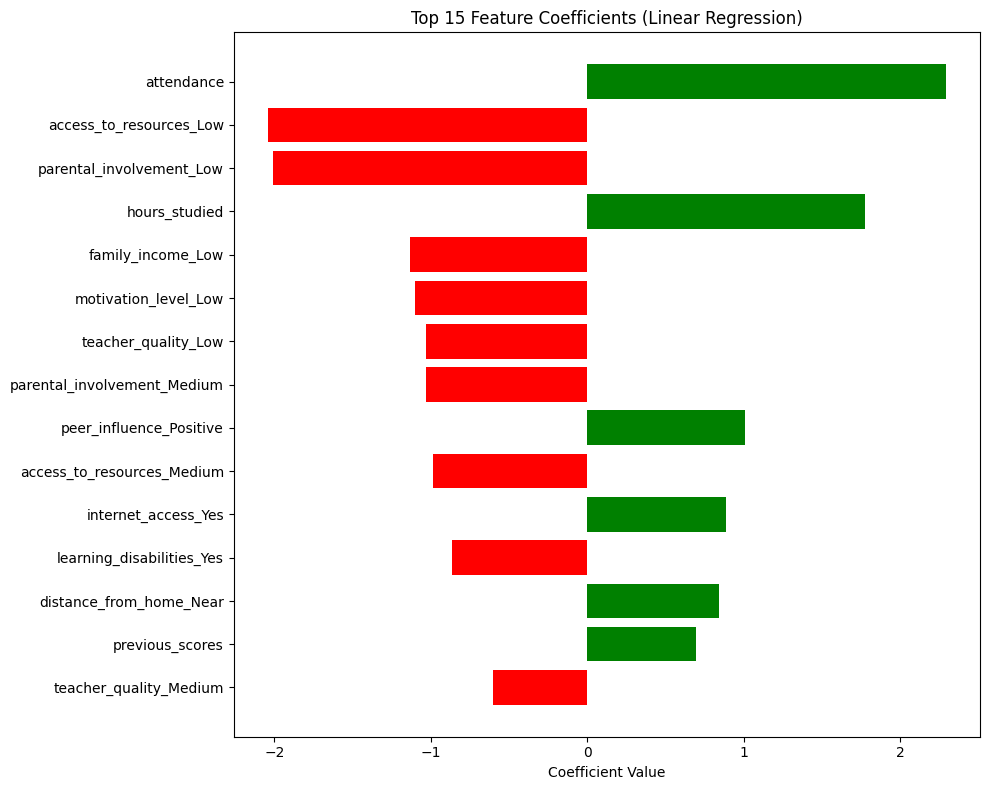

In [25]:
# Топ-15 признаков
plt.figure(figsize=(10, 8))
top_features = coef_df.head(15)
colors = ['green' if x > 0 else 'red' for x in top_features['coefficient']]
plt.barh(top_features['feature'], top_features['coefficient'], color=colors)
plt.xlabel('Coefficient Value')
plt.title('Top 15 Feature Coefficients (Linear Regression)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 4.3 Результаты Linear Regression



**Качество модели:**
- RMSE на тесте: 2.05 балла (ошибка ~3% от диапазона 55–101)
- R² на тесте: 0.731 (модель объясняет 73% дисперсии)
- Улучшение относительно baseline (предсказание среднего): 48.2%

**Ключевые факторы (топ-3 положительных):**
1. Attendance (+2.29) — посещаемость важнее всего
2. Hours studied (+1.78) — количество часов учёбы
3. Peer influence Positive (+1.01) — поддержка окружения

**Ключевые факторы риска (топ-3 отрицательных):**
1. Access to resources Low (-2.04) — нехватка ресурсов
2. Parental involvement Low (-2.01) — низкая вовлечённость родителей
3. Family income Low (-1.13) — низкий доход семьи

**Вывод:** Линейная регрессия показала хороший результат. Для улучшения стоит попробовать Random Forest, который лучше работает с категориальными признаками.

## 4.4 Случайный лес

**Создаём пайплайн предобработки**

In [26]:
# Пайплайн для Random Forest (тот же препроцессор)
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

**Обучение модели (по умолчанию)**

In [27]:
# Обучаем Random Forest
pipeline_rf.fit(X_train, y_train)

# Предсказываем
y_pred_train_rf = pipeline_rf.predict(X_train)
y_pred_test_rf = pipeline_rf.predict(X_test)

print("Random Forest обучен!")

Random Forest обучен!


**Настройка гиперпараметров (GridSearchCV)**

In [28]:
from sklearn.model_selection import GridSearchCV

# Параметры для перебора
param_grid = {
    'regressor__n_estimators': [50, 100],
    'regressor__max_depth': [5, 8, 10],
    'regressor__min_samples_split': [5, 10, 15],
    'regressor__min_samples_leaf': [2, 5, 8]
}

# Grid Search
grid_search = GridSearchCV(
    pipeline_rf,
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Оптимальные гиперпараметры: {grid_search.best_params_}")
print(f"RMSE на кросс-валидации: {-grid_search.best_score_:.4f}")

# Сохраняем настроенную модель Random Forest
tuned_rf = grid_search.best_estimator_


Fitting 5 folds for each of 54 candidates, totalling 270 fits
Оптимальные гиперпараметры: {'regressor__max_depth': 10, 'regressor__min_samples_leaf': 5, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 100}
RMSE на кросс-валидации: 2.4247


**Оценка качества (default vs tuned)**

In [29]:
# Функция для оценки
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name}: RMSE = {rmse:.4f}, R² = {r2:.4f}")
    return rmse, r2

print("\n=== Сравнение Random Forest (default vs tuned) ===\n")

# Default модель
rmse_train_rf, r2_train_rf = evaluate_model(y_train, y_pred_train_rf, "RF (default) Train")
rmse_test_rf, r2_test_rf = evaluate_model(y_test, y_pred_test_rf, "RF (default) Test")

print()

# Tuned модель
y_pred_train_tuned = tuned_rf.predict(X_train)
y_pred_test_tuned = tuned_rf.predict(X_test)

rmse_train_tuned, r2_train_tuned = evaluate_model(y_train, y_pred_train_tuned, "RF (tuned) Train")
rmse_test_tuned, r2_test_tuned = evaluate_model(y_test, y_pred_test_tuned, "RF (tuned) Test")


=== Сравнение Random Forest (default vs tuned) ===

RF (default) Train: RMSE = 0.9055, R² = 0.9463
RF (default) Test: RMSE = 2.4283, R² = 0.6205

RF (tuned) Train: RMSE = 1.9143, R² = 0.7599
RF (tuned) Test: RMSE = 2.3703, R² = 0.6385


**Сравнение с Linear Regression**

In [30]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest (default)', 'Random Forest (tuned)'],
    'Train RMSE': [rmse_train, rmse_train_rf, rmse_train_tuned],
    'Test RMSE': [rmse_test, rmse_test_rf, rmse_test_tuned],
    'Train R²': [r2_train, r2_train_rf, r2_train_tuned],
    'Test R²': [r2_test, r2_test_rf, r2_test_tuned]
})

print("\n=== Сравнение моделей ===")
print(results.to_string(index=False))


=== Сравнение моделей ===
                  Model  Train RMSE  Test RMSE  Train R²  Test R²
      Linear Regression    2.082222   2.045119  0.715945 0.730843
Random Forest (default)    0.905509   2.428303  0.946280 0.620533
  Random Forest (tuned)    1.914266   2.370255  0.759921 0.638459


**Визуализация сравнения**

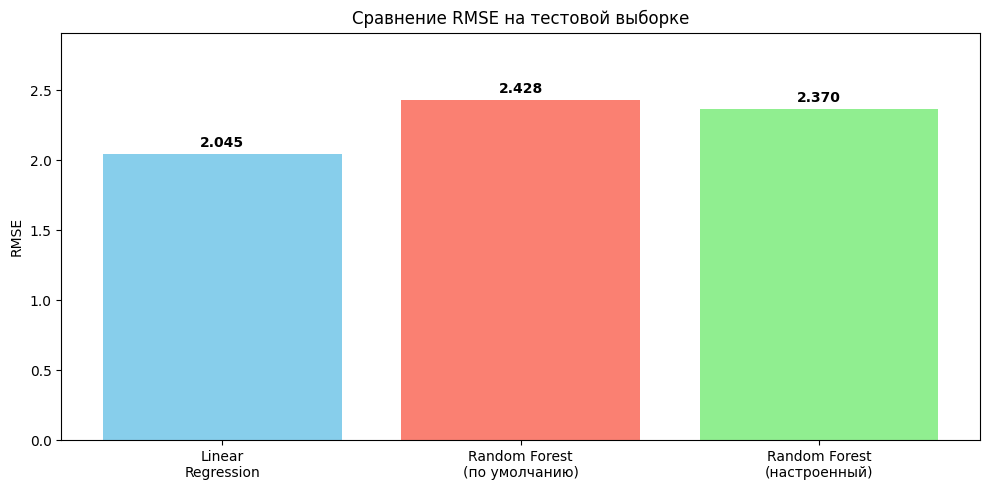

In [31]:
# График сравнения моделей
plt.figure(figsize=(10, 5))

# Данные для графика
models = ['Linear\nRegression', 'Random Forest\n(по умолчанию)', 'Random Forest\n(настроенный)']
test_rmse_values = [rmse_test, rmse_test_rf, rmse_test_tuned]

# Столбцы
bars = plt.bar(models, test_rmse_values, color=['skyblue', 'salmon', 'lightgreen'])
plt.ylabel('RMSE')
plt.title('Сравнение RMSE на тестовой выборке')
plt.ylim(0, max(test_rmse_values) * 1.2)

# Добавляем значения
for bar, val in zip(bars, test_rmse_values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.05, f'{val:.3f}',
             ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

**Важность признаков (Feature Importance)**

In [32]:
# Получаем важность признаков из Random Forest
feature_names = (numeric_features +
                 list(pipeline_rf.named_steps['preprocessor']
                      .named_transformers_['cat']
                      .get_feature_names_out(categorical_features)))

importances = pipeline_rf.named_steps['regressor'].feature_importances_

# Сортируем по важности
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("\n=== Топ-15 важнейших признаков (Random Forest) ===")
print(importance_df.head(15).to_string(index=False))


=== Топ-15 важнейших признаков (Random Forest) ===
                             feature  importance
                          attendance    0.387823
                       hours_studied    0.251832
                     previous_scores    0.099174
                   tutoring_sessions    0.042745
            parental_involvement_Low    0.023235
             access_to_resources_Low    0.020156
           learning_disabilities_Yes    0.014156
          access_to_resources_Medium    0.012794
                   family_income_Low    0.011626
             peer_influence_Positive    0.011290
      extracurricular_activities_Yes    0.011278
         parental_involvement_Medium    0.011189
              teacher_quality_Medium    0.010432
parental_education_level_High School    0.010404
             distance_from_home_Near    0.009868


**Визуализация важности признаков**

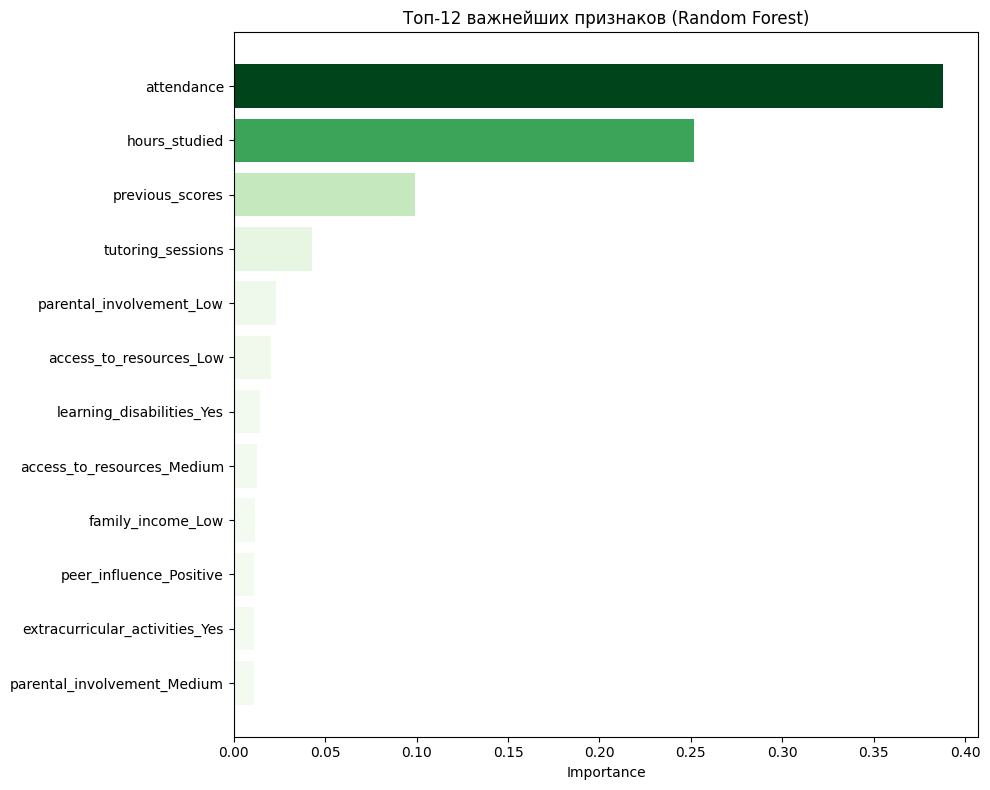

In [33]:
# График важности признаков (топ-12)
plt.figure(figsize=(10, 8))
top12 = importance_df.head(12)
colors = plt.cm.Greens(top12['importance'] / top12['importance'].max())

plt.barh(top12['feature'], top12['importance'], color=colors)
plt.xlabel('Importance')
plt.title('Топ-12 важнейших признаков (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 5. Финальные выводы



**Ключевые результаты:** Линейная регрессия показала лучшее качество, чем Random Forest.

| Модель | Test RMSE | Test R² |
|--------|-----------|---------|
| Linear Regression | 2.045 | 0.731 |
| Random Forest (default) | 2.428 | 0.620 |
| Random Forest (tuned) | 2.370 | 0.639 |

**Причины:**
1. В данных преобладают линейные зависимости (подтверждено scatter plots)
2. Линейная регрессия устойчива к переобучению
3. Random Forest переобучился, даже после настройки гиперпараметров

**Вывод:** Для данного датасета линейная модель предпочтительнее. Random Forest не дал улучшения.

## 5.1 Ограничения проекта

1. **Данные самоотчётные** — неизвестно, насколько объективны ответы (например, количество часов сна или учёбы)

2. **Отсутствует временная динамика** — данные срезовые, нельзя отследить изменения успеваемости во времени

3. **Пропуски в данных** — удалено 229 строк (3.5% данных), что может внести небольшое смещение

4. **Не все факторы учтены** — нет данных о качестве домашних заданий, психологическом состоянии студентов

5. **Линейная модель победила** — Random Forest не дал улучшения, что может быть связано с малым объёмом данных или их линейной структурой

## 5.2 Пути улучшения

1. **Собрать больше данных** — увеличить выборку для более устойчивых результатов

2. **Добавить новые признаки**:
   - Динамику изменений (было/стало)
   - Уровень стресса
   - Качество выполнения домашних заданий

3. **Попробовать другие модели**:
   - XGBoost / LightGBM (могут быть эффективнее Random Forest)
   - Lasso для автоматического отбора признаков

4. **Расширить предобработку** (сверх того, что уже сделано):
   - Целевое кодирование для категориальных признаков, вместо One-Hot Encoding (может быть эффективнее для категорий с многими значениями)
   - Создание признаков-взаимодействий (например, hours_studied × attendance)
   - Полиномиальные признаки для учёта нелинейностей

5. **SHAP для интерпретации** — объяснить каждое предсказание (особенно полезно для Random Forest)

6. **Проверить данные на выбросы** — возможно, удаление аномалий улучшит качество

## 5.3 Итоговое резюме

**Что сделано:**
- Проведён разведочный анализ (12 гипотез)
- Построены и сравнены 3 модели (Linear Regression, Random Forest default, Random Forest tuned)
- Выявлены ключевые факторы успеваемости

**Ключевые выводы о факторах успеваемости:**
1. **Attendance (посещаемость)** — самый сильный предиктор во всех моделях
2. **Hours studied** — второй по важности фактор
3. **Previous scores** влияет, но значительно слабее, чем ожидалось
4. **Отрицательные факторы** (Low): access_to_resources, parental_involvement, family_income, motivation_level — снижают балл на 1-2 пункта
5. **Sleep hours и Physical activity** не влияют на успеваемость

**Что касается моделей:**

- **Linear Regression** показала лучшее качество (RMSE = 2.05, R² = 0.73)
- Random Forest переобучился, даже после настройки
- Обе модели превзошли baseline

**Практическая ценность:**
- Увеличивайте **посещаемость** — это ключевой рычаг
- Поддерживайте **мотивацию** и **качество преподавания**
- Обратите внимание на студентов с **Low** показателями (ресурсы, доход, вовлечённость родителей)

**Что можно улучшить в будущем:**
- Добавить XGBoost и SHAP
- Увеличить выборку
- Учесть динамику изменений